# Machine Learning e Visão Computacional [T3] #
## Situação de Aprendizagem (Projeto Avaliativo) - Módulo 1 - Semana 14 ##

### Aluno: Henrique Tamaki ###

### OPÇÃO B: E-commerce Churn (Setor de Varejo) ###

O Problema: Um aplicativo de vendas precisa prever quais clientes estão prestes a abandonar a plataforma (alvo: Churn = 1) para oferecer cupons preventivos de retenção.

Desafio de Negócio: O que custa mais caro para o aplicativo: dar um cupom de desconto para quem já ia continuar comprando normalmente (Falso Positivo) ou perder um cliente em definitivo sem tentar retê-lo (Falso Negativo)?

Dataset original: https://drive.google.com/file/d/1Nbmt6Y_P1TjdFxsfTxfKQxKLkaNDJrT9/view?usp=sharing


Baixado e salvo em: dados/E Commerce Dataset - E Comm.csv

## Fase 1: Análise Exploratória de Dados (EDA)

## Descritiva e Estatística: ##

Exiba o tamanho total da base (linhas e colunas), os tipos de dados de cada variável e o sumário estatístico descritivo (médias, mínimos, máximos e quartis via .describe()) e etc.

In [1]:
# importacao bibliotecas usadas

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



sns.set_style("whitegrid")

In [2]:
# Tamanho da base e tipos de dados de cada variável
df = pd.read_csv("dados/E Commerce Dataset - E Comm.csv")

print(f"Linhas: {df.shape[0]} | Colunas: {df.shape[1]}")


Linhas: 5630 | Colunas: 20


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5630 entries, 0 to 5629
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   CustomerID                   5630 non-null   int64  
 1   Churn                        5630 non-null   int64  
 2   Tenure                       5366 non-null   float64
 3   PreferredLoginDevice         5630 non-null   str    
 4   CityTier                     5630 non-null   int64  
 5   WarehouseToHome              5379 non-null   float64
 6   PreferredPaymentMode         5630 non-null   str    
 7   Gender                       5630 non-null   str    
 8   HourSpendOnApp               5375 non-null   float64
 9   NumberOfDeviceRegistered     5630 non-null   int64  
 10  PreferedOrderCat             5630 non-null   str    
 11  SatisfactionScore            5630 non-null   int64  
 12  MaritalStatus                5630 non-null   str    
 13  NumberOfAddress              

In [4]:
# Sumário estatístico descritivo (médias, mínimos, máximos, quartis)

print("Sumário estatístico descritivo")

display(df.describe())          # variáveis numéricas
display(df.describe(include="str"))  # variáveis categóricas

Sumário estatístico descritivo


,CustomerID,Churn,Tenure,CityTier,WarehouseToHome,HourSpendOnApp,NumberOfDeviceRegistered,SatisfactionScore,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
count,5630.000000,5630.000000,5366.000000,5630.000000,5379.000000,5375.000000,5630.000000,5630.000000,5630.000000,5630.000000,5365.000000,5374.000000,5372.000000,5323.000000,5630.000000
mean,52815.500000,0.168384,10.189899,1.654707,15.639896,2.931535,3.688988,3.066785,4.214032,0.284902,15.707922,1.751023,3.008004,4.543491,177.221492
std,1625.385339,0.374240,8.557241,0.915389,8.531475,0.721926,1.023999,1.380194,2.583586,0.451408,3.675485,1.894621,2.939680,3.654433,49.193869
min,50001.000000,0.000000,0.000000,1.000000,5.000000,0.000000,1.000000,1.000000,1.000000,0.000000,11.000000,0.000000,1.000000,0.000000,0.000000
25%,51408.250000,0.000000,2.000000,1.000000,9.000000,2.000000,3.000000,2.000000,2.000000,0.000000,13.000000,1.000000,1.000000,2.000000,146.000000
50%,52815.500000,0.000000,9.000000,1.000000,14.000000,3.000000,4.000000,3.000000,3.000000,0.000000,15.000000,1.000000,2.000000,3.000000,163.000000
75%,54222.750000,0.000000,16.000000,3.000000,20.000000,3.000000,4.000000,4.000000,6.000000,1.000000,18.000000,2.000000,3.000000,7.000000,196.000000
max,55630.000000,1.000000,61.000000,3.000000,127.000000,5.000000,6.000000,5.000000,22.000000,1.000000,26.000000,16.000000,16.000000,46.000000,325.000000


,PreferredLoginDevice,PreferredPaymentMode,Gender,PreferedOrderCat,MaritalStatus
count,5630,5630,5630,5630,5630
unique,3,7,2,6,3
top,Mobile Phone,Debit Card,Male,Laptop & Accessory,Married
freq,2765,2314,3384,2050,2986


In [5]:
# Duplicados e valores nulos
print(f"Linhas duplicadas: {df.duplicated().sum()}")

print(" ")
print(" ")
print("Colunas e quantidades de nulos")
nulos = df.isnull().sum()
nulos = nulos[nulos > 0].sort_values(ascending=False)
percentual = (nulos / len(df) * 100).round(2)
pd.DataFrame({"qtd_nulos": nulos, "percentual (%)": percentual})

Linhas duplicadas: 0
 
 
Colunas e quantidades de nulos


,qtd_nulos,percentual (%)
DaySinceLastOrder,307,5.45
OrderAmountHikeFromlastYear,265,4.71
Tenure,264,4.69
OrderCount,258,4.58
CouponUsed,256,4.55
HourSpendOnApp,255,4.53
WarehouseToHome,251,4.46


Em um banco de dados de e-commerce, o termo `Tenure` refere-se ao tempo de vida ou tempo de relacionamento do cliente com a plataforma. É o período decorrido desde o momento em que o usuário realizou o seu cadastro (ou fez a sua primeira compra) até a data atual ou a data de sua última atividade.

## Visual: Plote no mínimo 3 gráficos explicativos ##

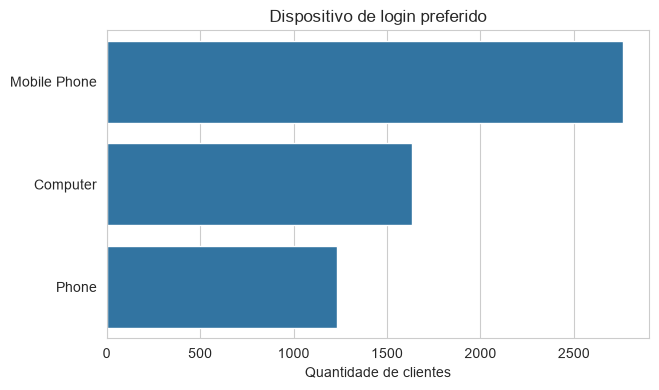

In [6]:
# Gráfico 1 - Barras: dispositivo de login preferido
plt.figure(figsize=(7, 4))
sns.countplot(y="PreferredLoginDevice", data=df, order=df["PreferredLoginDevice"].value_counts().index)
plt.title("Dispositivo de login preferido")
plt.xlabel("Quantidade de clientes")
plt.ylabel("")
plt.show()

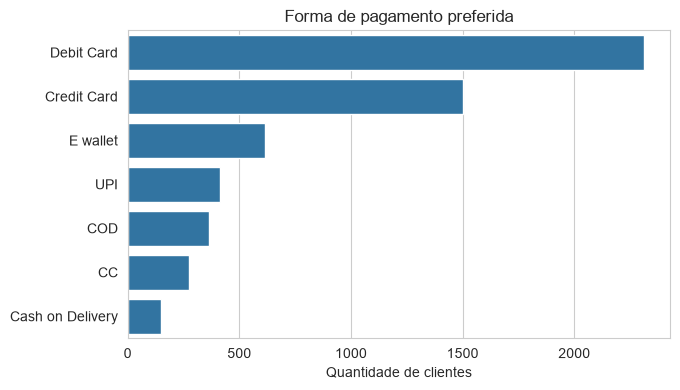

In [7]:
# Gráfico 2 - Barras: forma de pagamento preferida
plt.figure(figsize=(7, 4))
sns.countplot(y="PreferredPaymentMode", data=df, order=df["PreferredPaymentMode"].value_counts().index)
plt.title("Forma de pagamento preferida")
plt.xlabel("Quantidade de clientes")
plt.ylabel("")
plt.show()

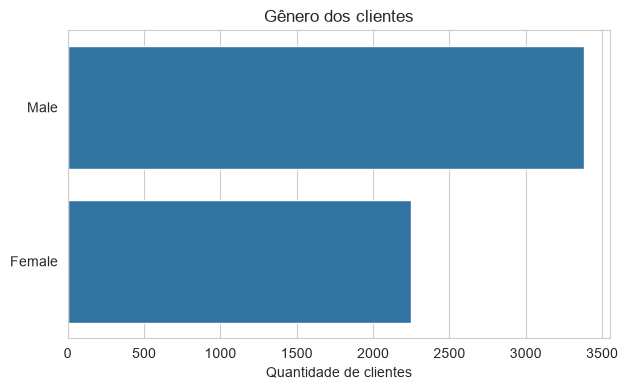

In [8]:
# Gráfico 3 - Barras: gênero
plt.figure(figsize=(7, 4))
sns.countplot(y="Gender", data=df, order=df["Gender"].value_counts().index)
plt.title("Gênero dos clientes")
plt.xlabel("Quantidade de clientes")
plt.ylabel("")
plt.show()

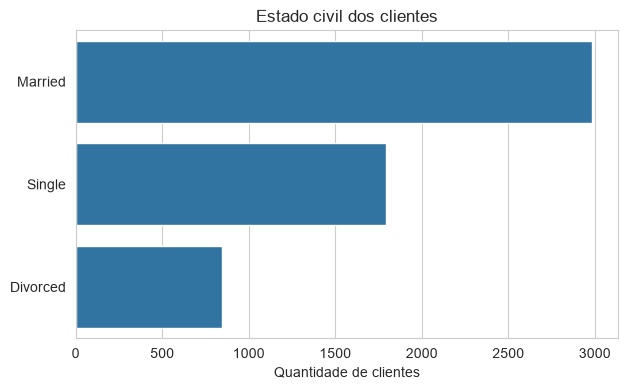

In [9]:
# Gráfico 4 - Barras: estado civil
plt.figure(figsize=(7, 4))
sns.countplot(y="MaritalStatus", data=df, order=df["MaritalStatus"].value_counts().index)
plt.title("Estado civil dos clientes")
plt.xlabel("Quantidade de clientes")
plt.ylabel("")
plt.show()

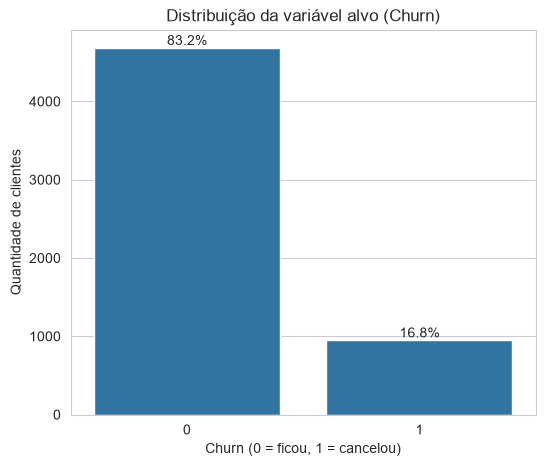

In [10]:
# Gráfico 5 - Barras: desbalanceamento da variável alvo (Churn)
plt.figure(figsize=(6, 5))
ax = sns.countplot(x="Churn", data=df)
plt.title("Distribuição da variável alvo (Churn)")
plt.xlabel("Churn (0 = ficou, 1 = cancelou)")
plt.ylabel("Quantidade de clientes")

total = len(df)
for p in ax.patches:
    pct = 100 * p.get_height() / total
    ax.annotate(f"{pct:.1f}%", (p.get_x() + p.get_width() / 2, p.get_height()),
                ha="center", va="bottom")
plt.show()


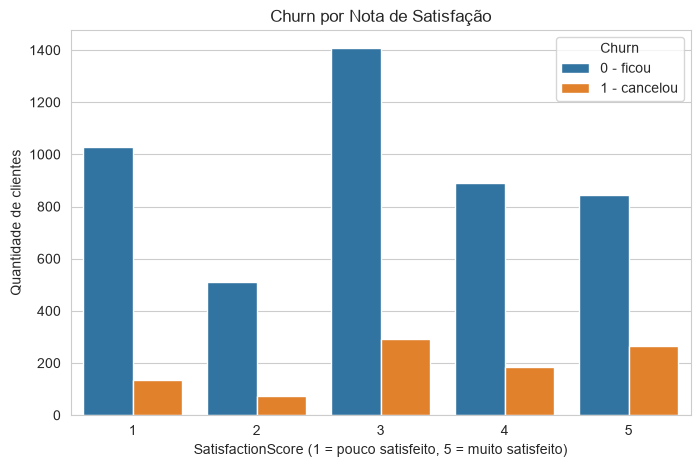

In [11]:
# Gráfico 6 - Barras: Churn por nível de satisfação (SatisfactionScore)
plt.figure(figsize=(8, 5))
sns.countplot(x="SatisfactionScore", hue="Churn", data=df)
plt.title("Churn por Nota de Satisfação")
plt.xlabel("SatisfactionScore (1 = pouco satisfeito, 5 = muito satisfeito)")
plt.ylabel("Quantidade de clientes")
plt.legend(title="Churn", labels=["0 - ficou", "1 - cancelou"])
plt.show()

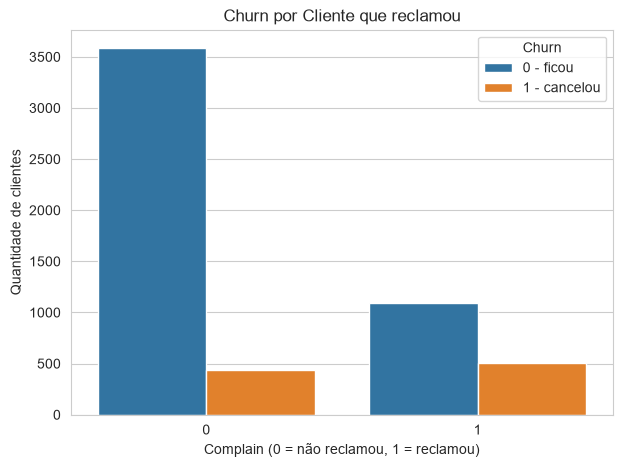

In [12]:
# Gráfico 7 - Barras: Churn por reclamação registrada (Complain)
plt.figure(figsize=(7, 5))
sns.countplot(x="Complain", hue="Churn", data=df)
plt.title("Churn por Cliente que reclamou")
plt.xlabel("Complain (0 = não reclamou, 1 = reclamou)")
plt.ylabel("Quantidade de clientes")
plt.legend(title="Churn", labels=["0 - ficou", "1 - cancelou"])
plt.show()

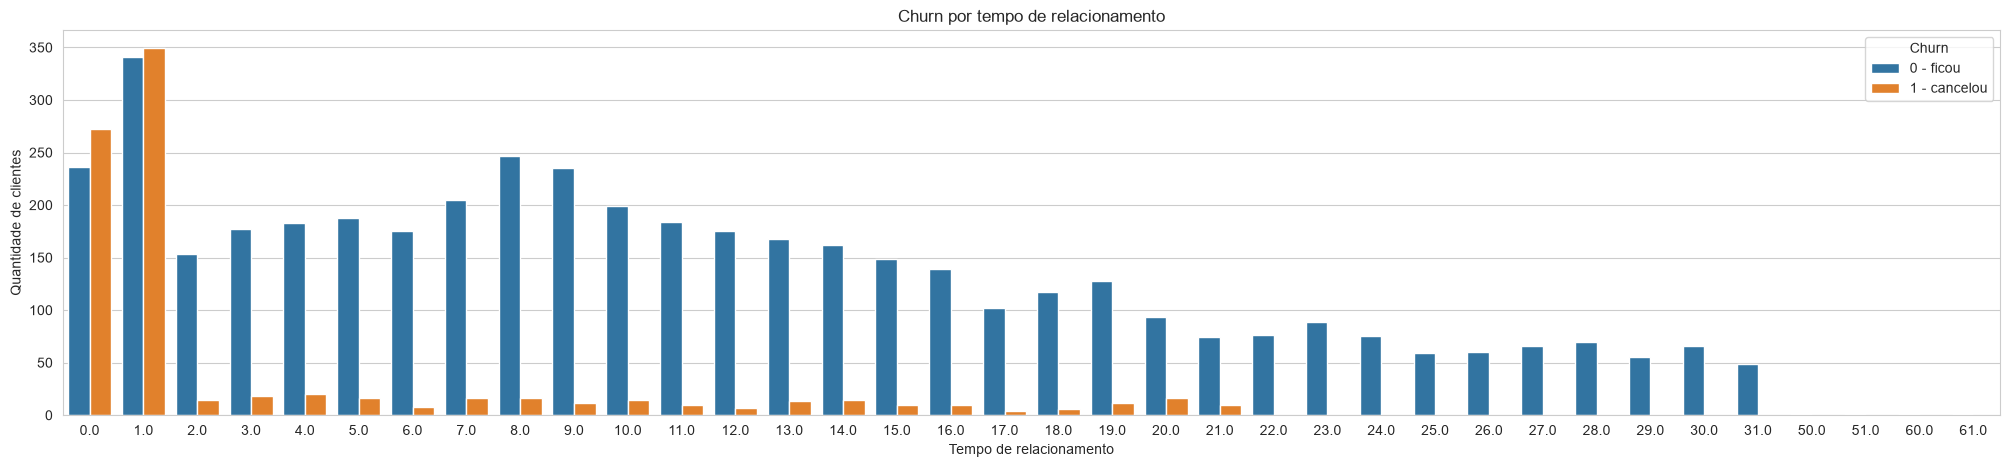

Obs: Pelo grafico parece que a unidade do Tenure são meses, mas nao tenho certeza


In [13]:
# Gráfico 8 - Barras: Churn por tempo de relacionamento (Tenure)
plt.figure(figsize=(25, 5))
sns.countplot(x="Tenure", hue="Churn", data=df)
plt.title("Churn por tempo de relacionamento")
plt.xlabel("Tempo de relacionamento")
plt.ylabel("Quantidade de clientes")
plt.legend(title="Churn", labels=["0 - ficou", "1 - cancelou"])
plt.show()

print("Obs: Pelo grafico parece que a unidade do Tenure são meses, mas nao tenho certeza")

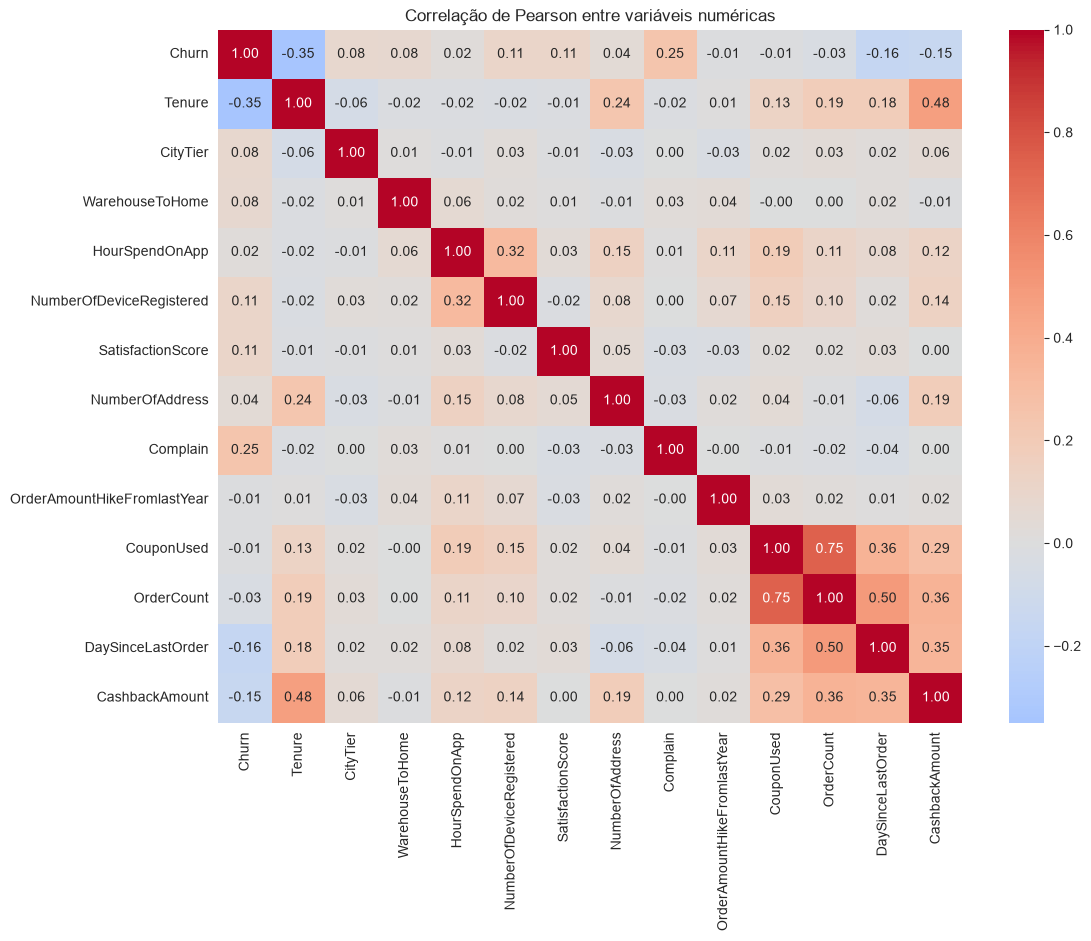

In [14]:
# Gráfico 9 - Mapa de calor: correlação de Pearson entre as variáveis numéricas
plt.figure(figsize=(12, 9))
corr = df.select_dtypes(include=np.number).drop(columns="CustomerID").corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlação de Pearson entre variáveis numéricas")
plt.show()



## Tomada de decisão (interpretação da EDA) ##

A base tem 5.630 linhas e 20 colunas, sem nenhuma linha duplicada. Sete colunas numéricas têm valores nulos (`Tenure`, `WarehouseToHome`, `HourSpendOnApp`, `OrderAmountHikeFromlastYear`, `CouponUsed`, `OrderCount`, `DaySinceLastOrder`), todas com no máximo ~5,5% de ausência — volume pequeno, mas que ainda precisa ser tratado.

O gráfico de barras confirma o desbalanceamento citado no desafio: apenas 948 clientes (16,8%) deram churn contra 4.682 (83,2%) que ficaram.

No mapa de calor, `Tenure` é a variável mais correlacionada inversamente com `Churn` (-0,35): clientes mais novos cancelam mais. Em seguida vêm `Complain` (+0,25 — quem reclama cancela mais). Nenhuma correlação é forte o suficiente para indicar causa predominante do churn de forma muito clara e transparente.

Até mesmo os mais obvios como `SatisfactionScore`não é afirmativo que será churn.


## Fase 2: Tratamento e Limpeza (Data Prep) ##

Nesta fase, vou limpar e preparar a base de dados para as próximas etapas. Primeiro, vou identificar e remover linhas duplicadas e verificar quais colunas possuem valores nulos. Depois, vou preencher esses valores usando a média ou a mediana, justificando a minha escolha de acordo com as características dos dados.

Também vou identificar os outliers, que são valores muito diferentes dos demais, usando gráficos ou análises simples. Em seguida, vou decidir se eles serão removidos, ajustados ou mantidos, explicando o motivo. Vou considerar que o KNN é mais sensível a esses valores, enquanto a Árvore de Decisão costuma lidar melhor com eles.

In [15]:
#Duplicadas: Identifique e remova linhas duplicadas que geram redundância.

# Duplicados e valores nulos
print(f"Linhas duplicadas: {df.duplicated().sum()}")

Linhas duplicadas: 0


Como não há duplicados, nennhum tratamento a ser realizado.

In [16]:
# Valores Nulos: Identifique as colunas com dados ausentes. É obrigatório justifi car textualmente a escolha da técnica de imputação: usou a Média (indicada para distribuições normais/simétricas) ou a Mediana (indicada para mitigar o impacto de outliers)?

print("Colunas e seus respectivos nulos")
nulos = df.isnull().sum()
nulos = nulos[nulos > 0].sort_values(ascending=False)
percentual = (nulos / len(df) * 100).round(2)
pd.DataFrame({"qtd_nulos": nulos, "percentual (%)": percentual})

Colunas e seus respectivos nulos


,qtd_nulos,percentual (%)
DaySinceLastOrder,307,5.45
OrderAmountHikeFromlastYear,265,4.71
Tenure,264,4.69
OrderCount,258,4.58
CouponUsed,256,4.55
HourSpendOnApp,255,4.53
WarehouseToHome,251,4.46


In [17]:
print("Colunas com dados nulos e respectivos dados estatísticos")

colunas_com_nulo = nulos.index.tolist()

resumo_nulos = pd.DataFrame({
    "media": df[colunas_com_nulo].mean(),
    "mediana": df[colunas_com_nulo].median(),
    "skew": df[colunas_com_nulo].skew(),
}).round(2)
display(resumo_nulos)

Colunas com dados nulos e respectivos dados estatísticos


,media,mediana,skew
DaySinceLastOrder,4.54,3.0,1.19
OrderAmountHikeFromlastYear,15.71,15.0,0.79
Tenure,10.19,9.0,0.74
OrderCount,3.01,2.0,2.20
CouponUsed,1.75,1.0,2.55
HourSpendOnApp,2.93,3.0,-0.03
WarehouseToHome,15.64,14.0,1.62


### Justificativa da imputação ###

- Em geral tivemos nulos de 4.46 a 5.45%, valores controlados para uso da media ou mediana.

- Também vou analisar o *skew* para verificar a assimetria dos dados. Quando o *skew* é positivo, significa que existem valores mais altos concentrados à direita da distribuição; quando é negativo, há valores mais baixos concentrados à esquerda. Um *skew* próximo de zero indica uma distribuição mais equilibrada, enquanto um valor como 3 representa uma forte assimetria positiva, com alguns valores muito altos influenciando a distribuição.

- `Tenure` (skew 0,74) e `OrderAmountHikeFromlastYear` (skew 0,79): assimetria moderada, média e mediana já diferem (10,19 vs 9,0 / 15,71 vs 15,0) → uso a **mediana**.

- `WarehouseToHome` (skew 1,62) e `DaySinceLastOrder` (skew 1,19): assimetria alta, boxplot mostra outliers acima do pavil superior → uso a **mediana**, para não deixar a imputação puxada pelos poucos clientes com valores muito altos.

- `CouponUsed` (skew 2,55) e `OrderCount` (skew 2,20): as mais assimétricas da base, com outliers evidentes no boxplot → uso a **mediana**.

- `HourSpendOnApp` (skew -0,03): distribuição praticamente simétrica, média e mediana quase iguais (2,93 vs 3,0) → aqui a **média** já seria segura, mas por consistência com o restante do pipeline uso a **mediana** também (diferença de resultado é desprezível nesse caso).

- ***Conclusão***: como a base é dominada por variáveis assimétricas com outliers, vide boxplot abaixo, a estratégia adotada para todas as colunas com nulo é a **input pela mediana**.

Boxplot das colunas com nulos


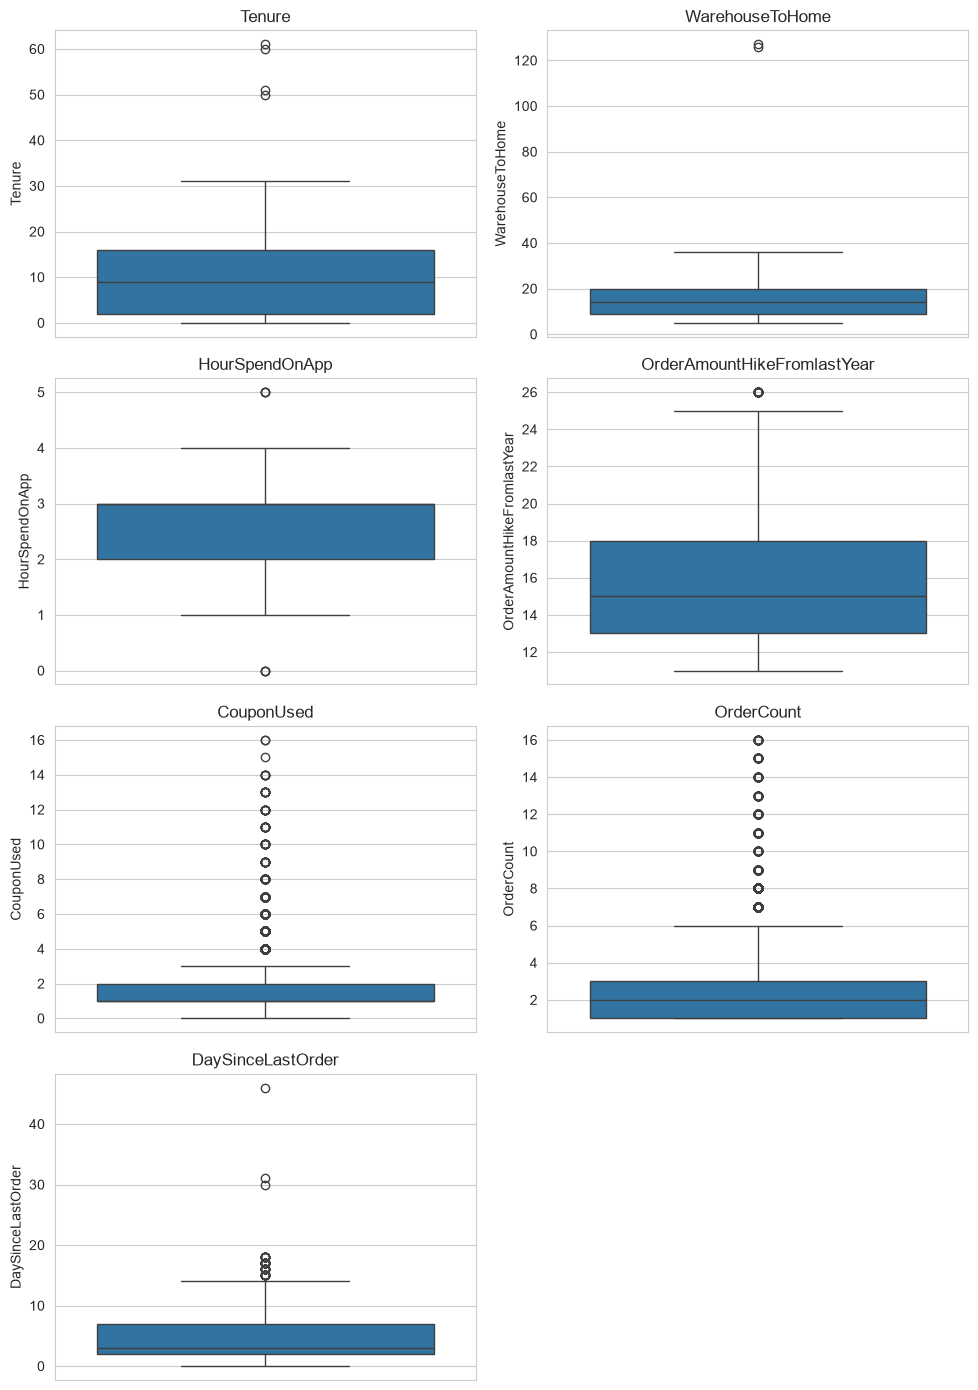

In [18]:
# Boxplots das colunas com nulo
fig, axes = plt.subplots(4, 2, figsize=(10, 14))

print("Boxplot das colunas com nulos")   

sns.boxplot(y=df["Tenure"], ax=axes[0, 0])
axes[0, 0].set_title("Tenure")

sns.boxplot(y=df["WarehouseToHome"], ax=axes[0, 1])
axes[0, 1].set_title("WarehouseToHome")

sns.boxplot(y=df["HourSpendOnApp"], ax=axes[1, 0])
axes[1, 0].set_title("HourSpendOnApp")

sns.boxplot(y=df["OrderAmountHikeFromlastYear"], ax=axes[1, 1])
axes[1, 1].set_title("OrderAmountHikeFromlastYear")

sns.boxplot(y=df["CouponUsed"], ax=axes[2, 0])
axes[2, 0].set_title("CouponUsed")

sns.boxplot(y=df["OrderCount"], ax=axes[2, 1])
axes[2, 1].set_title("OrderCount")

sns.boxplot(y=df["DaySinceLastOrder"], ax=axes[3, 0])
axes[3, 0].set_title("DaySinceLastOrder")

axes[3, 1].axis("off")  # espaço sobrando na grade (7 gráficos em 8 posições)

plt.tight_layout()
plt.show()

# Tratamento de valores nulos #

In [19]:
# Imputação: mediana de cada coluna, calculada e aplicada só nela mesma
for coluna in colunas_com_nulo:
    mediana = df[coluna].median()
    df[coluna] = df[coluna].fillna(mediana)

print("Nulos restantes por coluna:")
df[colunas_com_nulo].isnull().sum()

Nulos restantes por coluna:


DaySinceLastOrder              0
OrderAmountHikeFromlastYear    0
Tenure                         0
OrderCount                     0
CouponUsed                     0
HourSpendOnApp                 0
WarehouseToHome                0
dtype: int64

# Tratamento Outliers #

**O que é clipping e por que usar**

Clipping (ou capping/flooring) é uma técnica de tratamento de outliers que limita os valores extremos aos limites estatísticos do boxplot, em vez de excluir as observações inteiras.

Fórmula do método IQR
O boxplot usa o Intervalo Interquartil (IQR) para definir os "bigodes":
IQR = 𝑄3 − 𝑄1

Limite inferior=Q1−1,5×IQR
Limite superior=Q3+1,5×IQR

Onde:
Q1 = 25º percentil (primeiro quartil)
Q3 = 75º percentil (terceiro quartil)

Qualquer valor abaixo do limite inferior é substituído pelo próprio limite inferior. Qualquer valor acima do limite superior é substituído pelo limite superior

**Conclusão:** Desta forma não excluimos dados, principalmente os com churn = 1 que são importantes e já há desbalanceamento no dataset.

In [20]:
# Investiga outliers em TODAS as colunas numéricas (não categóricas), pela regra do boxplot (IQR)
colunas_numericas = df.select_dtypes(include=np.number).columns.tolist()
colunas_numericas.remove("CustomerID")  # é só um identificador, não é uma variável de verdade
colunas_numericas.remove("Churn")       # é o alvo que queremos prever, não uma variável explicativa

linhas = []
for coluna in colunas_numericas:
    Q1 = df[coluna].quantile(0.25)
    Q3 = df[coluna].quantile(0.75)
    IQR = Q3 - Q1
    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR

    qtd_outliers = ((df[coluna] < limite_inferior) | (df[coluna] > limite_superior)).sum()
    pct_outliers = round(100 * qtd_outliers / len(df), 1)

    linhas.append([coluna, round(df[coluna].skew(), 2), qtd_outliers, pct_outliers])

print("Diagnostico dos outliers")
resumo_outliers = pd.DataFrame(linhas, columns=["coluna", "skew", "qtd_outliers", "pct_outliers"])
resumo_outliers = resumo_outliers.sort_values("pct_outliers", ascending=False)
resumo_outliers

Diagnostico dos outliers


,coluna,skew,qtd_outliers,pct_outliers
10,OrderCount,2.28,703,12.5
9,CouponUsed,2.63,629,11.2
12,CashbackAmount,1.15,447,7.9
4,NumberOfDeviceRegistered,-0.40,397,7.1
11,DaySinceLastOrder,1.27,62,1.1
8,OrderAmountHikeFromlastYear,0.84,33,0.6
6,NumberOfAddress,1.09,4,0.1
3,HourSpendOnApp,-0.04,6,0.1
0,Tenure,0.77,4,0.1
1,CityTier,0.74,0,0.0


## Tratamento das colunas com outliers ##

In [21]:
# Clipping: trata só as colunas que a investigação acima mostrou ter outlier (qtd_outliers > 0)
colunas_outliers = resumo_outliers[resumo_outliers["qtd_outliers"] > 0]["coluna"].tolist()
print("Colunas com outlier a tratar:", colunas_outliers)

for coluna in colunas_outliers:
    Q1 = df[coluna].quantile(0.25)
    Q3 = df[coluna].quantile(0.75)
    IQR = Q3 - Q1

    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR

    df[coluna] = df[coluna].clip(lower=limite_inferior, upper=limite_superior)

print("Outliers tratados: valores extremos foram limitados aos limites do boxplot.")

Colunas com outlier a tratar: ['OrderCount', 'CouponUsed', 'CashbackAmount', 'NumberOfDeviceRegistered', 'DaySinceLastOrder', 'OrderAmountHikeFromlastYear', 'NumberOfAddress', 'HourSpendOnApp', 'Tenure', 'WarehouseToHome']
Outliers tratados: valores extremos foram limitados aos limites do boxplot.


In [22]:
# Verificação dos outliers apos tratamento
colunas_numericas = df.select_dtypes(include=np.number).columns.tolist()
colunas_numericas.remove("CustomerID")  # é só um identificador, não é uma variável de verdade
colunas_numericas.remove("Churn")       # é o alvo que queremos prever, não uma variável explicativa

linhas = []
for coluna in colunas_numericas:
    Q1 = df[coluna].quantile(0.25)
    Q3 = df[coluna].quantile(0.75)
    IQR = Q3 - Q1
    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR

    qtd_outliers = ((df[coluna] < limite_inferior) | (df[coluna] > limite_superior)).sum()
    pct_outliers = round(100 * qtd_outliers / len(df), 1)

    linhas.append([coluna, round(df[coluna].skew(), 2), qtd_outliers, pct_outliers])

print("Outliers tratados: valores extremos foram limitados aos limites do boxplot.")

resumo_outliers = pd.DataFrame(linhas, columns=["coluna", "skew", "qtd_outliers", "pct_outliers"])
resumo_outliers = resumo_outliers.sort_values("pct_outliers", ascending=False)
resumo_outliers

Outliers tratados: valores extremos foram limitados aos limites do boxplot.


,coluna,skew,qtd_outliers,pct_outliers
0,Tenure,0.69,0,0.0
1,CityTier,0.74,0,0.0
2,WarehouseToHome,0.94,0,0.0
3,HourSpendOnApp,-0.03,0,0.0
4,NumberOfDeviceRegistered,-0.30,0,0.0
5,SatisfactionScore,-0.14,0,0.0
6,NumberOfAddress,0.97,0,0.0
7,Complain,0.95,0,0.0
8,OrderAmountHikeFromlastYear,0.82,0,0.0
9,CouponUsed,0.53,0,0.0


**Impacto nos modelos**

- **KNN** calcula distância entre pontos. Um outlier bem longe distorce essa distância e pode enganar o modelo — por isso o clipping ajuda o KNN.
- **Árvore de Decisão** só faz perguntas do tipo "valor > X?", então um outlier isolado não muda a árvore quase nada — ela é robusta a isso, com ou sem o tratamento.

# Fase 3 - Feature Engineering #

(E-commerce): crie a coluna cashback_por_pedido = CashbackAmount / OrderCount.

In [23]:
# Criando nova coluna com a media de cashback por usuario

df["cashback_por_pedido"] = df["CashbackAmount"] / df["OrderCount"]

# Confere se sobrou algum problema (NaN ou infinito) mesmo assim
print("Nulos em cashback_por_pedido:", df["cashback_por_pedido"].isnull().sum())
print("Infinitos em cashback_por_pedido:", np.isinf(df["cashback_por_pedido"]).sum())

df[["CashbackAmount", "OrderCount", "cashback_por_pedido"]].head()

Nulos em cashback_por_pedido: 0
Infinitos em cashback_por_pedido: 0


,CashbackAmount,OrderCount,cashback_por_pedido
0,160,1.0,160.0
1,121,1.0,121.0
2,120,1.0,120.0
3,134,1.0,134.0
4,130,1.0,130.0


In [24]:
# Sumário estatístico descritivo da nova coluna (médias, mínimos, máximos, quartis)

print("Sumário estatístico descritivo - Cashback por pedido")

df["cashback_por_pedido"].describe()


Sumário estatístico descritivo - Cashback por pedido


count    5630.000000
mean       96.257738
std        50.480359
min        11.833333
25%        56.000000
50%        87.000000
75%       129.000000
max       271.000000
Name: cashback_por_pedido, dtype: float64

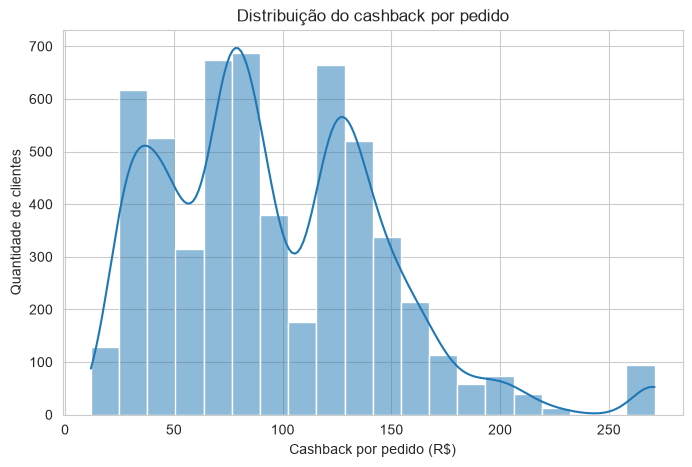

In [25]:
# Histograma: distribuição do cashback por pedido
plt.figure(figsize=(8, 5))
sns.histplot(df["cashback_por_pedido"], bins=20, kde=True)
plt.title("Distribuição do cashback por pedido")
plt.xlabel("Cashback por pedido (R$)")
plt.ylabel("Quantidade de clientes")
plt.show()